# Tutorial 05: MCMC Fitting with emcee

## Overview

Tutorial 04 ended with a best-fit point and the warning that it is a starting position, not
a result. This tutorial turns it into a posterior.

It is about the **mechanics of running a chain**: where to start the walkers, how to size
it, how to run it in parallel without tripping over Python's multiprocessing, how to tell
whether it converged, and how to save it so a five-hour run is never lost.

## Learning Objectives

By the end of this tutorial, you will:

- Know how to start walkers, and why a good starting point saves hours
- Be able to size a chain from a single timing measurement
- Know the `__main__` guard rule for running chains in scripts
- Be able to judge convergence three ways: acceptance fraction, autocorrelation time, R-hat
- Know how to choose burn-in from the traces rather than by habit
- Be able to save, resume and reload a chain
- Know how to quote a result from the samples

## Prerequisites

- **Tutorial 04: Basic Fitting Workflow** — we continue with its data and its best fit

In [1]:
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# If FitTeD was installed with `pip install -e .` this block is unnecessary.
# It is here so the notebooks also work from a bare checkout.
package_dir = Path().resolve().parent
if str(package_dir) not in sys.path:
    sys.path.append(str(package_dir))   # append, so an installed copy wins

import fitted
fitted.format_plots()

print("FitTeD", fitted.__version__)


  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward.j.r.nathan@gmail.com




FitTeD 2.0.0


## Setup: the data set from Tutorial 04

The Swift XRT light curve plus the late-time UVW1 band. Tutorial 04 showed that the UV band
is what makes this problem well posed, so we keep it.

In [2]:
from astropy import units

examples = package_dir / 'fitted' / 'examples'
D_Mpc = 236.4

raw = np.genfromtxt(examples / '2019dsg_Xray.txt', skip_header=3)
kind = np.genfromtxt(examples / '2019dsg_Xray.txt', skip_header=3,
                     usecols=(1), dtype=str)
scale = 4 * np.pi * (D_Mpc * units.Mpc.to(units.cm))**2
detected, limit = kind == 'X', kind == 'XUL'

uv = np.genfromtxt(examples / '2019dsg_UVW1.txt')
t_uv, L_uv, e_uv = uv[:, 0], uv[:, 1], uv[:, 2]
NU_UVW1 = 1.198891e15
late = t_uv > 150.0

data_set = fitted.data.Data_Set(
    args_X=[[raw[:, 0][detected], raw[:, 2][detected] * scale,
             raw[:, 3][detected] * scale, [0.3, 10]]],
    bands_X=['Swift XRT'],
    args_X_upperlim=[[raw[:, 0][limit], raw[:, 2][limit] * scale,
                      3 * np.ones(limit.sum()), [0.3, 10]]],
    bands_X_upperlim=['Swift XRT upper limit'],
    args_UV=[[t_uv[late], L_uv[late], e_uv[late], NU_UVW1]],
    bands_UV=['UVW1'],
    global_systematic=0.1,
)

model = fitted.models.GR_disc(data=data_set, decay=False)
fit = fitted.Fit(model=model)
names = list(model.default_key_pars)
ndim = len(names)
print("%d parameters, %d detections + %d upper limits"
      % (ndim, detected.sum() + late.sum(), limit.sum()))

No default colour for band UVW1, colour for this band currently default matplotlib colour 0.
7 parameters, 25 detections + 14 upper limits


## Step 1: where to start the walkers

`run_chain` scatters `nwalkers` walkers in a small ball around one point, controlled by
`scatter` (a *fractional* spread). Where you put that ball matters more than almost any
other setting:

- **Start near the posterior** and burn-in is short — the walkers spend their time sampling.
- **Start far away** and the first few hundred steps are just the ensemble walking downhill.
  You pay for those steps and then throw them away.
- **Start too tightly** (`scatter` very small) in a high-dimensional space and the ensemble
  can take a long time to expand to the posterior width.
- **Start too loosely** and some walkers land outside the prior, where the probability is
  `-inf`, and they are stuck until a move happens to rescue them.

A quick `best_fit` is the cheapest way to find a sensible centre, which is exactly what
Tutorial 04 produced.

In [3]:
import time

start = model.pack_parameters(log_mh=7.0, a_bh=0.01, m_disc=0.05, r0=30.0,
                              tvi=15.0, t0=-2.0, incl=70.0)
p0 = fit.best_fit(start, print_best_fit=False,
                  options={'maxiter': 20000, 'maxfev': 20000})
print("walker centre: log L = %.2f" % fit.log_likelihood(p0))

# Check the whole starting ball is inside the prior. A walker that starts at -inf
# is a wasted walker.
rng = np.random.default_rng(42)
ball = p0 * (1 + 1e-3 * rng.standard_normal((64, ndim)))
finite = np.isfinite([fit.log_prior(p) for p in ball])
print("%d of %d trial walkers start inside the prior" % (finite.sum(), len(ball)))

walker centre: log L = -30.32
64 of 64 trial walkers start inside the prior


## Step 2: size the chain

The cost of a chain is `nwalkers × nsteps` likelihood evaluations. Measure one evaluation
and you can predict the wall clock before you commit to it — do this before every long run.

Rules of thumb for `nwalkers`: emcee requires more than `2 × ndim`, and in practice 50–200
is the useful range. More walkers explore better per step and parallelise better; they do
not reduce the number of *steps* you need.

In [4]:
fit.log_likelihood(p0)                       # warm up the compiled kernels first
t = time.time()
for _ in range(20):
    fit.log_likelihood(p0)
ms = (time.time() - t) / 20 * 1e3

print("%.1f ms per likelihood evaluation\n" % ms)
print("%-10s %-10s %12s %12s" % ("nwalkers", "nsteps", "evaluations", "CPU time"))
for nw, ns in ((48, 800), (64, 2000), (100, 5000), (200, 10000)):
    n = nw * ns
    print("%-10d %-10d %12d %10.0f s" % (nw, ns, n, n * ms / 1e3))

14.6 ms per likelihood evaluation

nwalkers   nsteps      evaluations     CPU time
48         800               38400        562 s
64         2000             128000       1872 s
100        5000             500000       7314 s
200        10000           2000000      29256 s


## Step 3: run it

```python
fit.run_chain(
    full_pars=p0,          # centre of the initial walker ball (sampled space)
    nwalkers=100,
    nsteps=1000,
    scatter=1e-3,          # fractional spread of the ball
    backend_path='chain.h5',   # HDF5 file, written as it goes
    overwrite_backend=False,   # False resumes an existing file
    progress=True,
    use_parallel=True,     # multiprocessing across walkers
    n_workers=None,        # defaults to min(nwalkers, cpu_count())
    moves=None,            # None + use_optimized_moves=True gives a tuned mixture
    check_convergence=False,
)
```

!!! warning "The `__main__` guard, in scripts"

    In a notebook `use_parallel=True` is safe. In a **script** it is not, unless the call is
    guarded:

    ```python
    if __name__ == "__main__":
        fit.run_chain(...)
    ```

    Python's `multiprocessing` spawn start method — the default on macOS and Windows —
    re-imports your script inside every worker. Without the guard, each worker re-executes
    the whole file top to bottom, including your `run_chain` call. The symptom is a run that
    silently happens twice, or an inscrutable bootstrapping error.

    In a notebook `__main__` is the kernel, so there is nothing to re-execute. This is why
    the same code can work in Jupyter and fail as a script.

In [5]:
NWALKERS, NSTEPS = 64, 1500
print("%d x %d = %d evaluations, ~%.0f s of CPU time"
      % (NWALKERS, NSTEPS, NWALKERS * NSTEPS, NWALKERS * NSTEPS * ms / 1e3))

t = time.time()
fit.run_chain(
    full_pars=p0,
    nwalkers=NWALKERS,
    nsteps=NSTEPS,
    scatter=1e-3,
    backend_path='tutorial05_chain.h5',
    overwrite_backend=True,
    progress=False,          # a progress bar does not render well in a saved notebook
    use_parallel=True,
)
wall = time.time() - t
print("\nfinished in %.0f s (%.0f evaluations/s)"
      % (wall, NWALKERS * NSTEPS / wall))
print("chain shape (nsteps, nwalkers, ndim):", fit.chain.shape)

64 x 1500 = 96000 evaluations, ~1404 s of CPU time
Existing tutorial05_chain.h5 has been deleted



  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward.j.r.nathan@gmail.com



  _____  _  _   _____      ____   
 |  ___|(_)| |_|_   _|___ |  _ \  
 | |_   | || __| | | / _ \| | | | 
 |  _|  | || |_  | ||  __/| |_| | 
 |_|    |_| \__| |_| \___||____/  
                                  
   FITing TransiEnts with Discs   

 Version 2.0.0
 manyTDE compatible?  Yes

 FitTeD was created by Andrew Mummery* and Edward Nathan$.

 Please cite us if you make use of this code
 https://ui.adsabs.harvard.edu/abs/2025MNRAS.544.2225M/abstract

 * amummery@ias.edu
 $ edward


finished in 504 s (191 evaluations/s)
chain shape (nsteps, nwalkers, ndim): (1500, 64, 7)


## Step 4: did it converge? Three checks

### Acceptance fraction

The fraction of proposed moves that were accepted, per walker. Roughly **0.2–0.5** is
healthy. Very low means the proposals are nearly all rejected — usually a badly scaled or
strongly curved posterior. Very high (above ~0.7) usually means the walkers are barely
moving.

### Autocorrelation time

emcee's own diagnostic, and the most useful one: how many steps the chain takes to forget
where it was. Your number of *independent* samples is roughly
`nsteps × nwalkers / τ`. emcee refuses to give an estimate at all unless the chain is at
least ~50τ long, and that refusal is itself the answer — if it complains, the chain is too
short.

### R-hat (Gelman–Rubin)

Compares the spread *between* walkers with the spread *within* each walker. If the walkers
still remember where they started, the between-walker spread is too small and R-hat exceeds
1. Below about 1.01 is the usual criterion.

In [6]:
acc = fit.sampler.acceptance_fraction
print("acceptance fraction: mean %.3f, range %.3f to %.3f"
      % (acc.mean(), acc.min(), acc.max()))

try:
    tau = fit.sampler.get_autocorr_time()
    print("\nautocorrelation time: %s" % np.array2string(tau, precision=1))
    print("independent samples ~ %.0f" % (NSTEPS * NWALKERS / tau.max()))
except Exception as exc:
    tau = fit.sampler.get_autocorr_time(quiet=True)
    print("\nemcee will not certify the autocorrelation time:")
    print("   %s" % str(exc).split('\n')[0])
    print("best estimate anyway: %s" % np.array2string(tau, precision=1))
    print("chain is %d steps; ~%.0f x tau_max would be needed"
          % (NSTEPS, 50 * tau.max() / NSTEPS))

The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
N/50 = 30;
tau: [119.14500107 117.37406252 111.05206393  82.51713471 142.1776045
  97.73836939 103.3199799 ]


acceptance fraction: mean 0.171, range 0.085 to 0.218

emcee will not certify the autocorrelation time:
   The chain is shorter than 50 times the integrated autocorrelation time for 7 parameter(s). Use this estimate with caution and run a longer chain!
best estimate anyway: [119.1 117.4 111.1  82.5 142.2  97.7 103.3]
chain is 1500 steps; ~5 x tau_max would be needed


In [7]:
f_discard = 0.5
rhat = fit.compute_rhat(f_discard=f_discard)
print("R-hat after discarding the first %.0f%% (want < 1.01):" % (100 * f_discard))
for name, r in zip(names, rhat):
    print("  %-11s %6.3f %s" % (name, r, "" if r < 1.01 else "  <-- not converged"))
print("\nworst: %.3f" % rhat.max())

R-hat after discarding the first 50% (want < 1.01):
  log_mh       1.415   <-- not converged
  a_bh         1.430   <-- not converged
  log_m_disc   1.382   <-- not converged
  log_r0       1.144   <-- not converged
  log_tvi      1.176   <-- not converged
  t0           1.346   <-- not converged
  cos_incl     1.295   <-- not converged

worst: 1.430


### And look at the traces

The check people skip, and the one that tells you what is actually happening. What you want
is walkers that lose all memory of their starting point early and then wander around a
stationary band. What you do not want:

- a steady drift in one direction — not converged, keep going;
- a walker on a flat line for hundreds of steps — stuck, usually against a prior boundary;
- several distinct bands — walkers trapped in separate modes.

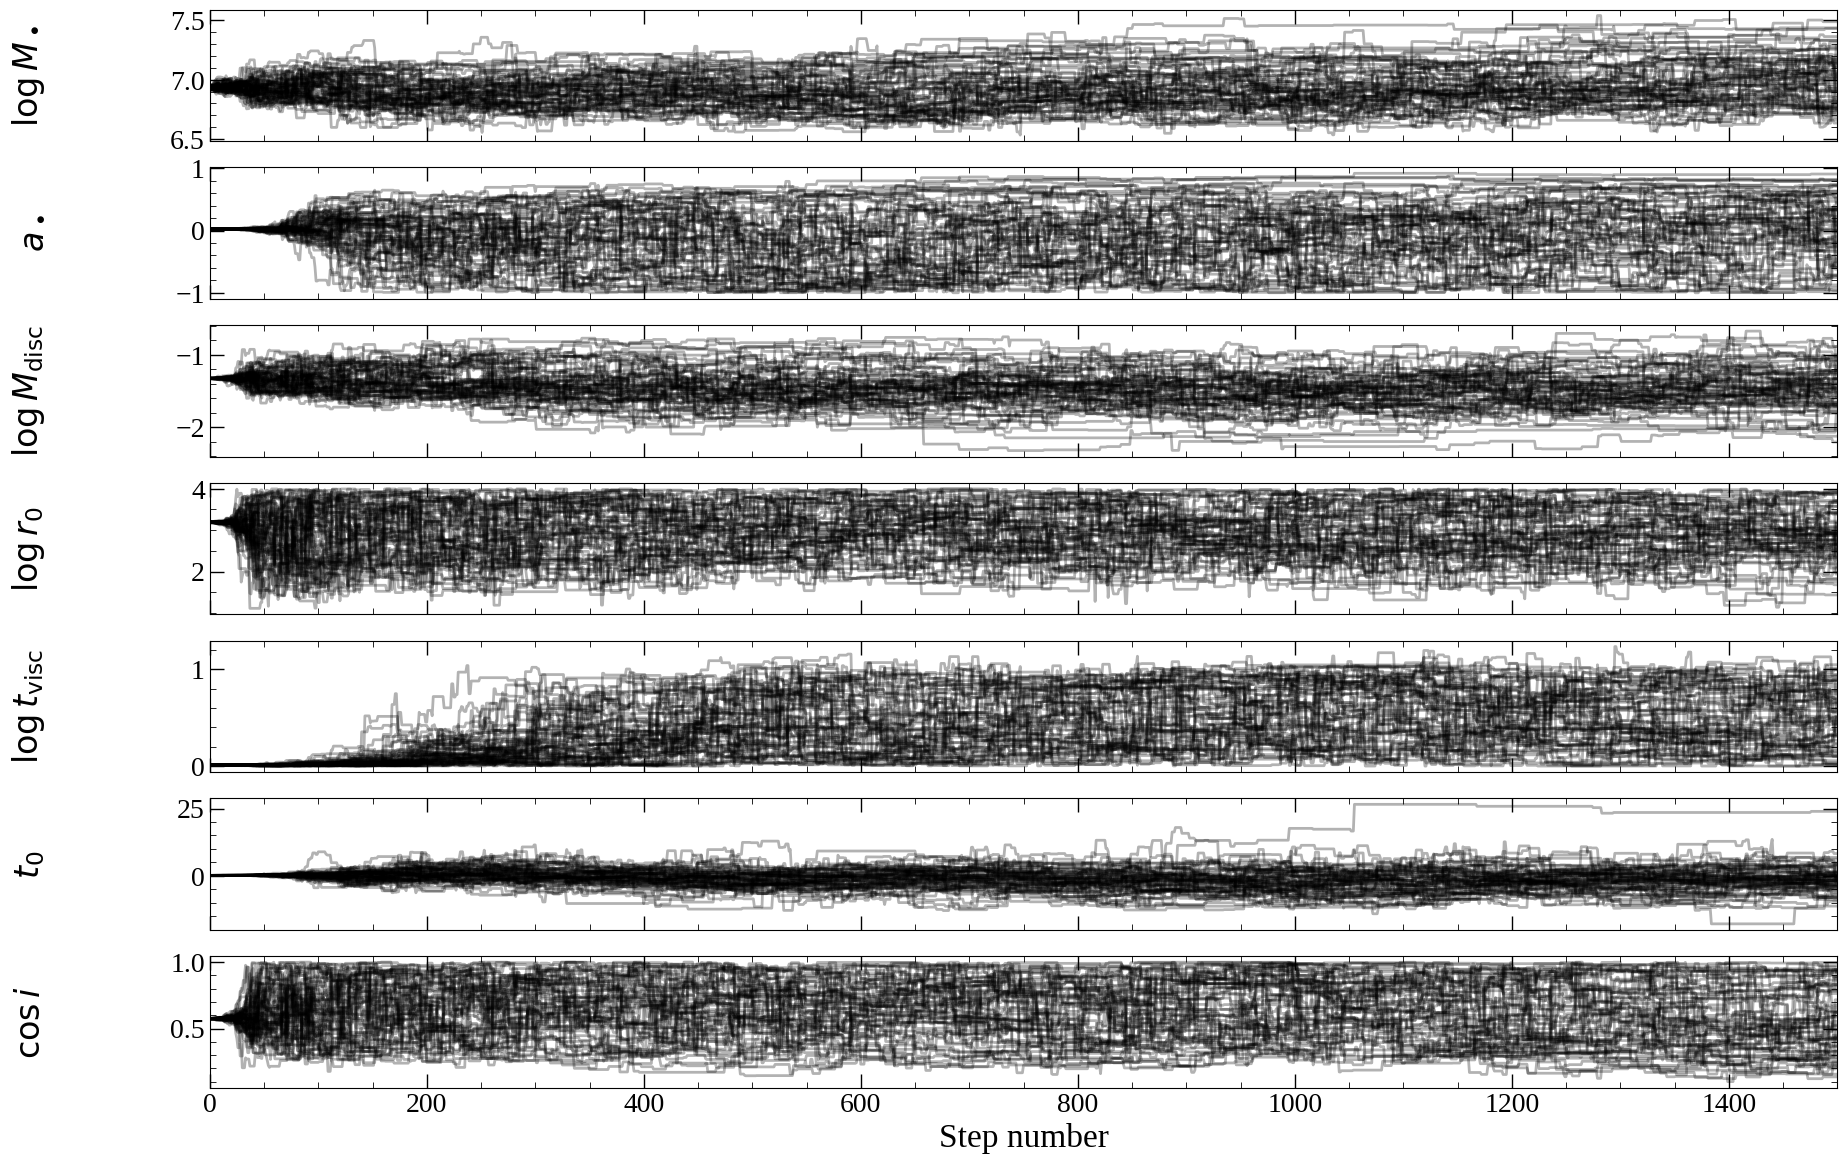

In [8]:
fig = fit.plot_walkers(just_disc=True)
plt.show()

## Step 5: choose burn-in from the traces

`f_discard` is the fraction thrown away as burn-in. Pick it by looking at the traces —
discard up to the point where the ensemble stops drifting — rather than by habit.

A quick numerical check: split the retained chain in half and compare the two halves. If
burn-in is adequate, the two halves have the same distribution.

In [9]:
chain = fit.chain
for f in (0.0, 0.3, 0.5, 0.7):
    kept = chain[int(f * len(chain)):]
    half = len(kept) // 2
    a = kept[:half].reshape(-1, ndim)
    b = kept[half:].reshape(-1, ndim)
    shift = np.abs(np.median(a, axis=0) - np.median(b, axis=0))
    scale = np.std(kept.reshape(-1, ndim), axis=0)
    print("discard %3.0f%%: %5d steps kept, worst half-to-half median shift %.2f sigma"
          % (100 * f, len(kept), np.max(shift / scale)))

discard   0%:  1500 steps kept, worst half-to-half median shift 1.09 sigma
discard  30%:  1050 steps kept, worst half-to-half median shift 0.31 sigma
discard  50%:   750 steps kept, worst half-to-half median shift 0.39 sigma
discard  70%:   450 steps kept, worst half-to-half median shift 0.31 sigma


## Step 6: quote a result

Percentiles, not means: percentiles commute with the log and cosine transforms, so the
median of `log_m_disc` really is the log of the median of `m_disc`. Means do not.

Always say which space you are quoting in.

In [10]:
flat = chain[int(f_discard * len(chain)):].reshape((-1, ndim))
q = np.percentile(flat, [16, 50, 84], axis=0)

flat_phys = np.array([model.convert_parameters(s, names) for s in flat])
qp = np.percentile(flat_phys, [16, 50, 84], axis=0)
physical_names = ['log_mh', 'a_bh', 'm_disc', 'r0', 'tvi', 't0', 'incl']

print("%d samples after discarding %.0f%%\n" % (len(flat), 100 * f_discard))
print("%-11s %24s   %-9s %s" % ("sampled", "median (+/-)", "physical", "median (+/-)"))
for i, (sn, pn) in enumerate(zip(names, physical_names)):
    print("%-11s %9.3f +%.3f -%.3f   %-9s %9.4g +%.3g -%.3g"
          % (sn, q[1, i], q[2, i] - q[1, i], q[1, i] - q[0, i],
             pn, qp[1, i], qp[2, i] - qp[1, i], qp[1, i] - qp[0, i]))

48000 samples after discarding 50%

sampled                 median (+/-)   physical  median (+/-)
log_mh          6.930 +0.249 -0.164   log_mh         6.93 +0.249 -0.164
a_bh           -0.011 +0.573 -0.673   a_bh       -0.01065 +0.573 -0.673
log_m_disc     -1.493 +0.271 -0.266   m_disc      0.03214 +0.0279 -0.0147
log_r0          2.910 +0.742 -0.653   r0            812.7 +3.68e+03 -632
log_tvi         0.516 +0.363 -0.350   tvi           3.282 +4.29 -1.81
t0             -1.731 +4.313 -4.733   t0           -1.731 +4.31 -4.73
cos_incl        0.606 +0.289 -0.270   incl          52.67 +17.7 -26.2


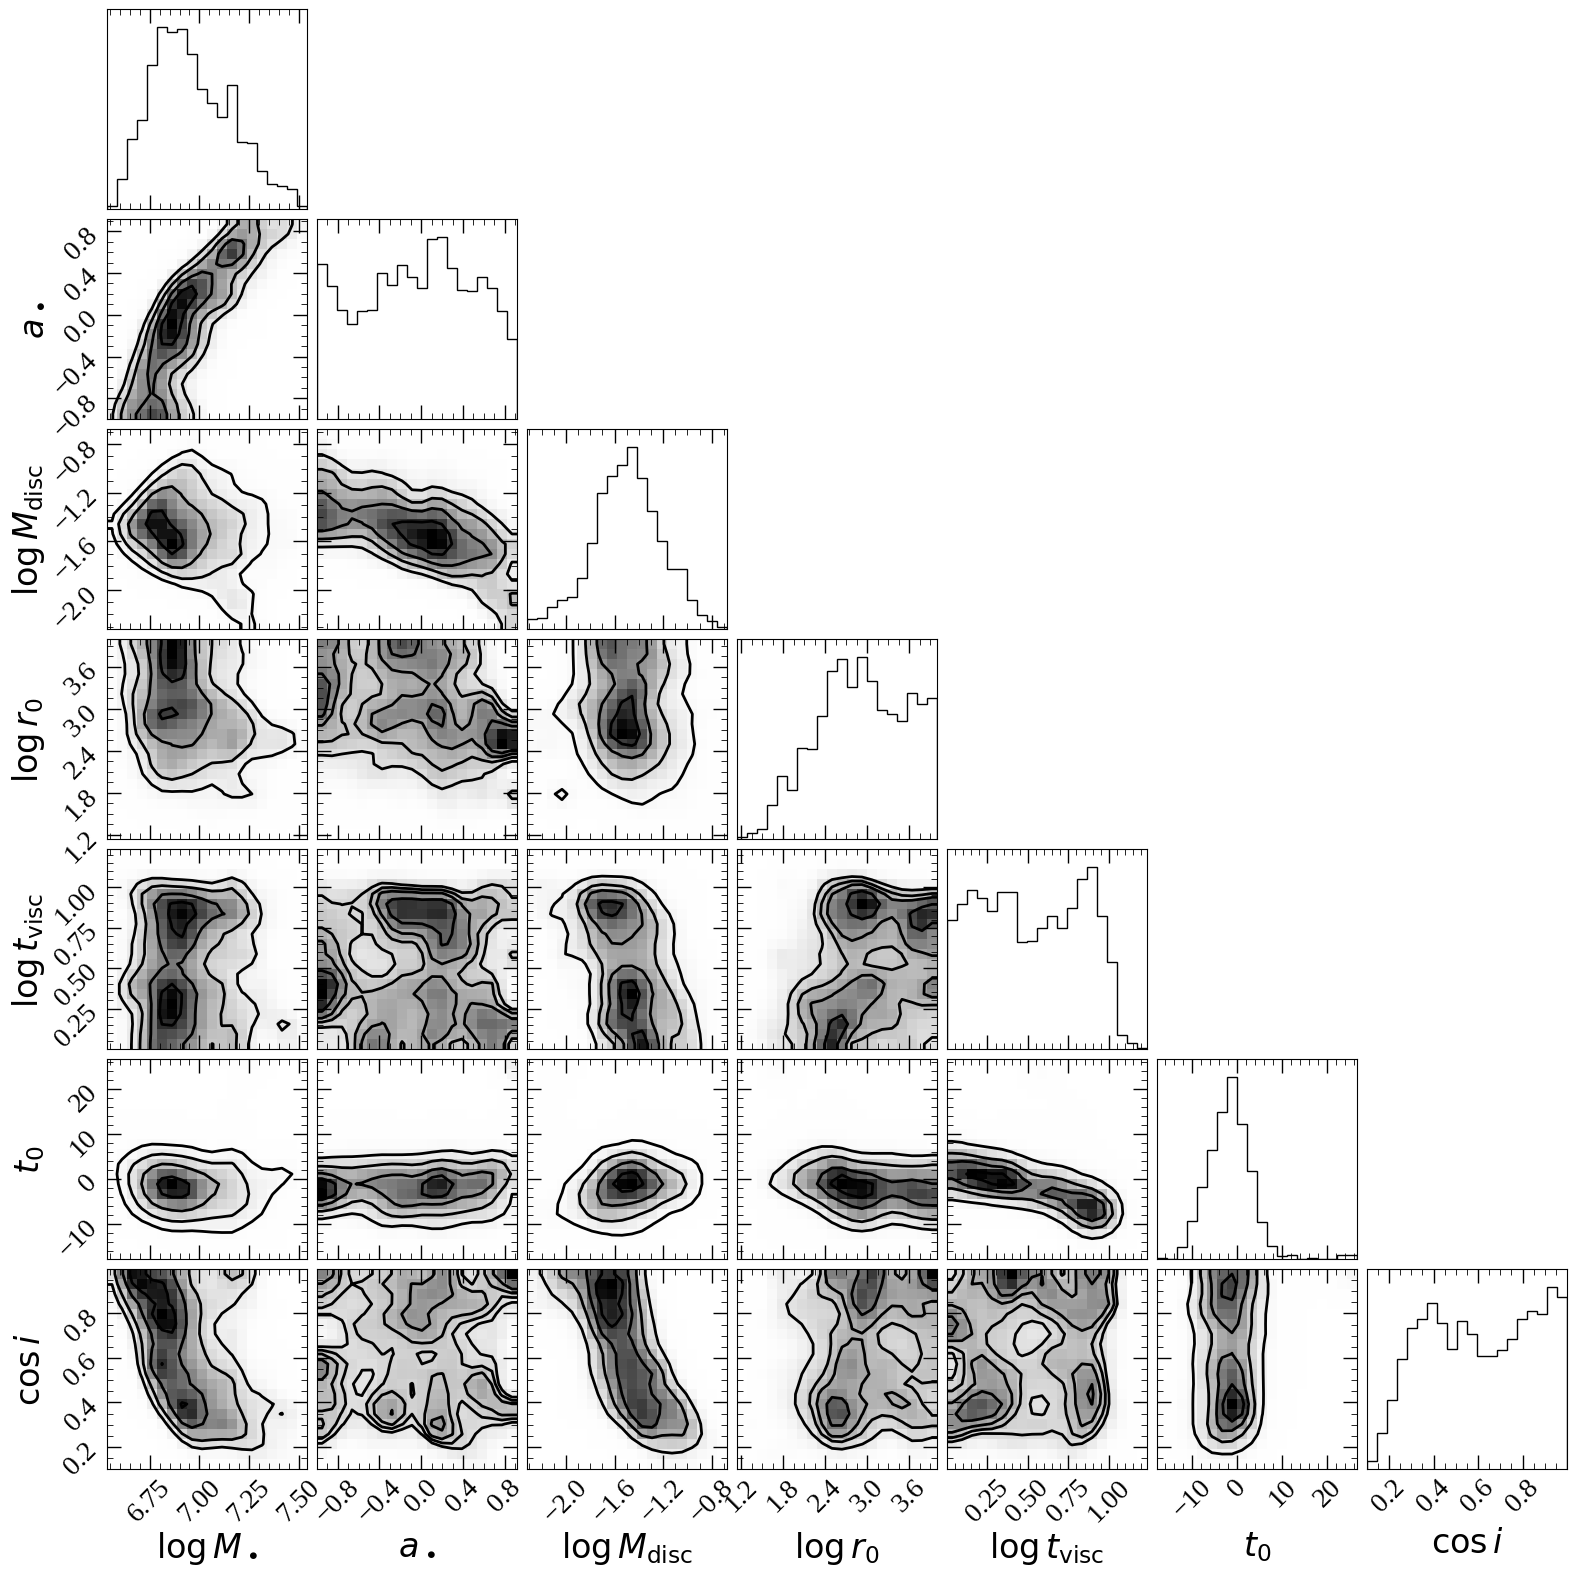

In [11]:
fig = fit.plot_corner(just_disc=True, f_discard=f_discard)
plt.show()

The corner plot is where the degeneracies become visible — the ridges are pairs of
parameters that trade off against each other, and they are why a single best-fit point is
misleading no matter how good the optimiser is.

## Step 7: save, resume, reload

Two mechanisms, for two purposes.

**The HDF5 backend** is written incrementally *as the chain runs*, so a job killed at step
1800 of 2000 is not a chain lost. It is also how you extend a chain: point at the same file
with `overwrite_backend=False` and ask for more steps.

**The pickle** stores the finished article — model, data and chain together — which is what
you want when you come back in six months to regenerate a figure.

In [12]:
import os

print("backend written during the run: %s (%.1f MB)"
      % ('tutorial05_chain.h5', os.path.getsize('tutorial05_chain.h5') / 1e6))

# Read it back independently of the Fit object, the way you would in a later session.
import emcee
backend = emcee.backends.HDFBackend('tutorial05_chain.h5', read_only=True)
print("backend holds a chain of shape %s" % (backend.get_chain().shape,))
print("log-probabilities available: %s" % (backend.get_log_prob().shape,))

# To continue this chain later:
#   fit.run_chain(backend_path='tutorial05_chain.h5', nsteps=1000,
#                 overwrite_backend=False)
#
# To store everything together:
#   fit.save('at2019dsg_xray_uv')      # -> at2019dsg_xray_uv_FIT.pickle

backend written during the run: tutorial05_chain.h5 (13.3 MB)
backend holds a chain of shape (1500, 64, 7)
log-probabilities available: (1500, 64)


## Settings for a real run

| Setting | Here | Publication |
|---------|------|-------------|
| `nwalkers` | 64 | 100–200 |
| `nsteps` | 1500 | let `check_convergence` decide; expect several thousand |
| `f_discard` | 0.5 | chosen from the traces |
| `backend_path` | used | always, for anything long |
| convergence | checked afterwards | `check_convergence=True`, `target_rhat=1.01`, `min_steps=500` |

`check_convergence=True` evaluates R-hat every `convergence_check_interval` steps and stops
once every parameter is below `target_rhat`, after at least `min_steps`. That is better than
guessing `nsteps` — but read the diagnostics anyway. A chain can stop early because a
parameter is genuinely unconstrained rather than because it is well sampled.

## Summary

- Start walkers from a `best_fit` result, and check the whole ball is inside the prior.
- Size the chain from one timing measurement before committing to it.
- Guard `run_chain` with `if __name__ == "__main__":` in scripts.
- Check three things: acceptance fraction, autocorrelation time, R-hat — then look at the
  traces anyway.
- Choose burn-in from the traces; verify by comparing halves of what you keep.
- Quote medians and percentiles, and say which space they are in.
- Use the HDF5 backend for anything long, and `fit.save()` when you are done.

## Next steps

- **Tutorial 06: Complete Workflow** — all six bands, the early-time model, end to end
- **Tutorial 07: Model Options Reference** — the accuracy and performance options

## Further reading

- emcee documentation: https://emcee.readthedocs.io/
- Goodman & Weare (2010), the stretch move emcee is built on
- **Paper Section 3**: statistical analysis (arXiv:2408.15048)